Epoch: 000, New_w: 8.52,  New_b: 3.97,  Loss: 2374.12
Epoch: 050, New_w: 11.29,  New_b: 12.13,  Loss: 234.22
Epoch: 100, New_w: 10.21,  New_b: 18.21,  Loss: 157.18
Epoch: 150, New_w: 9.32,  New_b: 23.19,  Loss: 105.54
Epoch: 200, New_w: 8.60,  New_b: 27.27,  Loss: 70.93
Epoch: 250, New_w: 8.00,  New_b: 30.60,  Loss: 47.73
Epoch: 300, New_w: 7.52,  New_b: 33.34,  Loss: 32.18
Epoch: 350, New_w: 7.12,  New_b: 35.57,  Loss: 21.76
Epoch: 400, New_w: 6.79,  New_b: 37.41,  Loss: 14.77
Epoch: 450, New_w: 6.53,  New_b: 38.91,  Loss: 10.09
Epoch: 500, New_w: 6.31,  New_b: 40.13,  Loss: 6.95
Epoch: 550, New_w: 6.13,  New_b: 41.14,  Loss: 4.84
Epoch: 600, New_w: 5.98,  New_b: 41.96,  Loss: 3.43
Epoch: 650, New_w: 5.86,  New_b: 42.64,  Loss: 2.49
Epoch: 700, New_w: 5.76,  New_b: 43.19,  Loss: 1.86
Epoch: 750, New_w: 5.68,  New_b: 43.64,  Loss: 1.43
Epoch: 800, New_w: 5.62,  New_b: 44.01,  Loss: 1.15
Epoch: 850, New_w: 5.56,  New_b: 44.31,  Loss: 0.95
Epoch: 900, New_w: 5.52,  New_b: 44.56,  Loss: 0

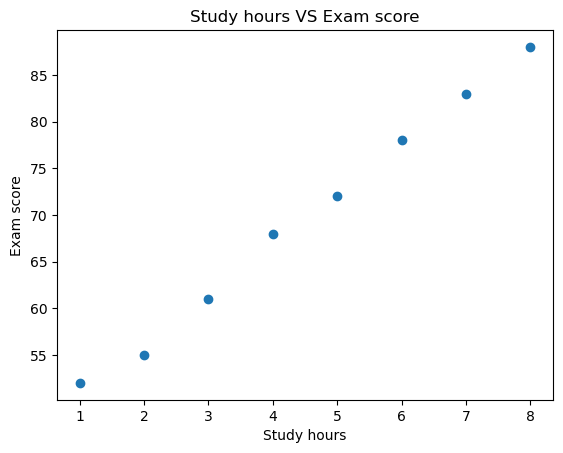

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1,2,3,4,5,6,7,8], dtype=float)
y = np.array([52,55,61,68,72,78,83,88], dtype=float)

plt.scatter(X,y)
plt.title("Study hours VS Exam score")
plt.xlabel("Study hours")
plt.ylabel("Exam score")

# Initial parameters 
w = 4 
b = 3
learning_rate = 0.01

for epoch in range(1000):
    
    # First prediction
    y_pred = X*w + b

    # Loss
    n = len(X)
    loss = np.mean((y - y_pred)**2)

    # Gradients (Batch gradient)
    dw =-2 * np.mean((y - y_pred) * X)
    db =-2 * np.mean((y - y_pred))

    # Update parameters 

    w = w - learning_rate*dw
    b = b - learning_rate*db
    
    if epoch % 50 == 0:
        print(f"Epoch: {epoch:03}, New_w: {w:.2f},  New_b: {b:.2f},  Loss: {loss:.2f}")
        

    




Weights:
[ 0.82894365  0.17853146 -0.13794939  0.15669182  0.01681517 -0.04522857
 -0.48705563 -0.45147126]

Bias:
2.071857488844901

Final cost:
0.27386194648571244


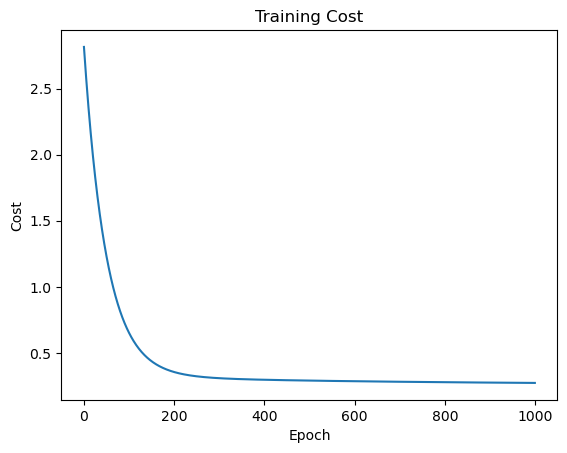

Test MSE: 0.5671852986082032
Test RMSE: 0.7531170550506762
Test R²: 0.5671692517174325
R²: 56.72%


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# 1. Load dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3. Standardization
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# 4. Initialize parameters
n_features = X_train.shape[1]

w = np.zeros(n_features)
b = 0.0

# 5. Training settings
learning_rate = 0.01
epochs = 1000

m = len(X_train)

cost_history = []

# 6. Gradient descent
for epoch in range(epochs):

    # Prediction
    y_pred = X_train @ w + b

    # Cost
    cost = (1 / (2 * m)) * np.sum(
        (y_pred - y_train) ** 2
    )

    # Gradients
    dw = (1 / m) * (
        X_train.T @ (y_pred - y_train)
    )

    db = (1 / m) * np.sum(
        y_pred - y_train
    )

    # Update
    w -= learning_rate * dw
    b -= learning_rate * db

    cost_history.append(cost)


print("Weights:")
print(w)

print("\nBias:")
print(b)

print("\nFinal cost:")
print(cost_history[-1])

plt.plot(cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost")

plt.show()


# Testing
y_pred_test = X_test @ w + b

mse = np.mean((y_test - y_pred_test) ** 2)

print("Test MSE:", mse)

rmse = np.sqrt(mse)

print("Test RMSE:", rmse)

ss_res = np.sum((y_test - y_pred_test) ** 2) # Unpredicted variation
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2) # Total variation

# R2 = predicted variation / total variation 
# total variation  = unpredicted variation + predicted variation 

r2 = 1 - (ss_res / ss_tot)

print("Test R²:", r2)

accuracy_percentage = r2 * 100
print(f"R²: {accuracy_percentage:.2f}%")


In [ ]:


# Regularization: is restricting model on what it learns i.e. Make the model learn only general patters not in deep specific patterns that can lead to overfitting

# Without regularization the only aim or goal of the model is to minimize the cost function , this can make the model learn specific patterns from the data in order to minimize the loss which can make it overfit


